# OSRS NPC Classification Model
# Eval evaluation

Load model traind in previous notebook and run evaluation + viz

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/Computer Vision/cv-final-clean.zip', 'r') as z:
    z.extractall('/content/cv-final')

Mounted at /content/drive


In [11]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

In [3]:
df = pd.read_csv('/content/cv-final/data/npc.csv')

# cleaning (should mirror cleaning we wrote in the EDA)
# TODO: EDA notebook should output a cleaned csv that this model uses and then we skip cleaning here
df["Gender"] = df["Gender"].apply(lambda x: x if x in ("Male", "Female") else "Other")
df["Members"] = df["Members"].replace("? (edit)", "Yes")
df = df.rename(columns={"Race": "Class"})
df["Class"] = df["Class"].replace({
    "Citizen of Arceuus": "Human",
    "Dwarf ( Imcando-descendant )": "Dwarf"
})
df["has_chathead"] = df["id"].apply(lambda i: os.path.exists(f"/content/cv-final/data/chatheads/{i}.png"))
df["has_body"] = df["id"].apply(lambda i: os.path.exists(f"/content/cv-final/data/bodies/{i}.png"))

# one img corrupted
# TODO: what is this? how did it get corrupted? fixable?
corrupt = {4231}
df = df[~df["id"].isin(corrupt)].reset_index(drop=True)

# filter to NPCs with both images
# TODO: should we let the model still make a prediction on NPCs even if the chathead is missing? --> yes!
df = df[df["has_chathead"] & df["has_body"]].reset_index(drop=True)
print(f"Working dataset: {len(df)} NPCs")

Working dataset: 3467 NPCs


In [4]:
# collapse to top 10 classes + Other
TOP_CLASSES = df["Class"].value_counts().head(10).index.tolist()
df["label"] = df["Class"].apply(lambda x: x if x in TOP_CLASSES else "Other")

CLASS_NAMES = TOP_CLASSES + ["Other"]
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
df["label_idx"] = df["label"].map(class_to_idx)

print(df["label"].value_counts())

label
Human         2097
Other          582
Dwarf          248
Elf            149
Gnome          139
Vampyre         60
Ghost           49
Monkey          42
Dorgeshuun      40
Troll           31
Cat             30
Name: count, dtype: int64


In [5]:
# 70/15/15 split — must match training notebook exactly
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label_idx"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label_idx"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 2426 | Val: 520 | Test: 521


In [6]:
eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class NPCDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        chathead = Image.open(f"/content/cv-final/data/chatheads/{row['id']}.png").convert("RGB")
        body = Image.open(f"/content/cv-final/data/bodies/{row['id']}.png").convert("RGB")
        return self.transform(chathead), self.transform(body), row["label_idx"]

class DualCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # two separate resnet18 backbones, one for chathead one for body
        self.chathead_cnn = models.resnet18(weights="IMAGENET1K_V1")
        self.body_cnn = models.resnet18(weights="IMAGENET1K_V1")
        # remove final classification layer from both
        self.chathead_cnn.fc = nn.Identity()
        self.body_cnn.fc = nn.Identity()
        # concatenate both 512-dim feature vectors -> classify
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, chathead, body):
        f1 = self.chathead_cnn(chathead)
        f2 = self.body_cnn(body)
        return self.classifier(torch.cat([f1, f2], dim=1))

test_loader = DataLoader(NPCDataset(test_df, eval_transform), batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")
model = DualCNN(num_classes=len(CLASS_NAMES)).to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/Computer Vision/npc_classifier.pth', map_location=device))
model.eval()
print("Model loaded.")

Using: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


Model loaded.


# Classification report
Monkey and Cat: are perfect - visually very distinct, model nails them despite few examples

Ghost: 100% precision but 38% recall - when it predicts Ghost it's always right, but it misses 62% of actual Ghosts,
probably predicting them as Other or Human

Dwarf: dropped from 100% to 59% recall - surprising given how well it did before. More classes may be confusing the boundary
Dorgeshuun and Troll: great recall - model finds them reliably despite tiny support (4-6 examples)

In [7]:
# per-class breakdown
all_preds, all_labels = [], []
with torch.no_grad():
    for chathead, body, labels in test_loader:
        preds = model(chathead.to(device), body.to(device)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


              precision    recall  f1-score   support

       Human       0.89      0.92      0.90       315
       Dwarf       0.96      0.59      0.73        37
         Elf       1.00      0.78      0.88        23
       Gnome       0.90      0.86      0.88        21
     Vampyre       0.89      0.89      0.89         9
       Ghost       1.00      0.38      0.55         8
      Monkey       1.00      1.00      1.00         6
  Dorgeshuun       0.86      1.00      0.92         6
       Troll       0.80      1.00      0.89         4
         Cat       1.00      1.00      1.00         4
       Other       0.70      0.81      0.75        88

    accuracy                           0.86       521
   macro avg       0.91      0.84      0.85       521
weighted avg       0.87      0.86      0.86       521



# Confusion matrix
See where model confused classes, see what ghosts and dwarf got confused with (since they had recall issues)

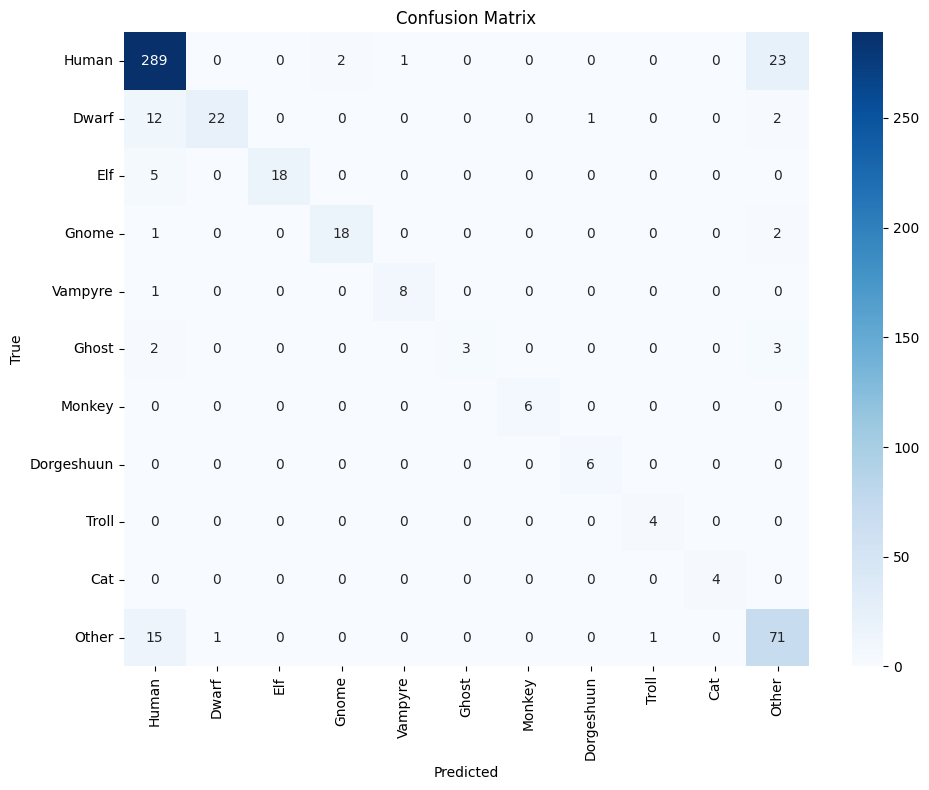

In [12]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Make some predictions!

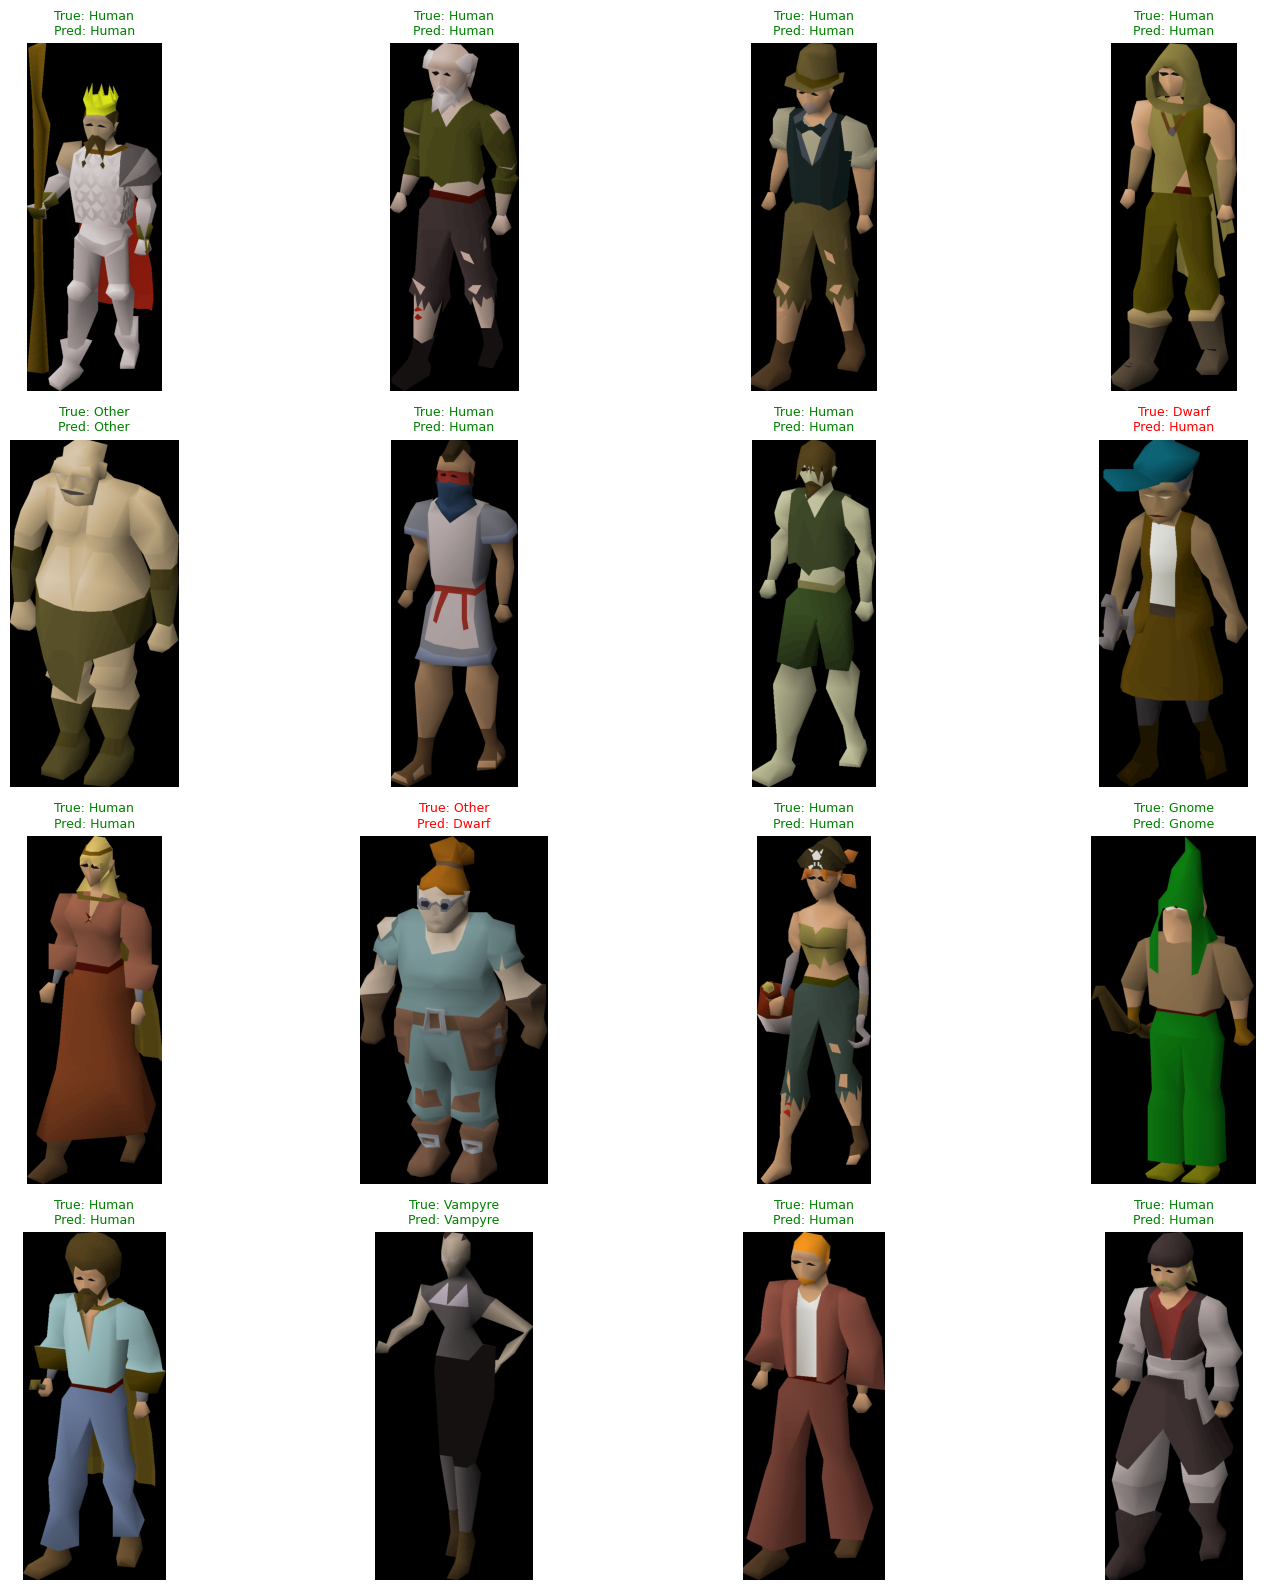

In [13]:
# 16-image grid of predictions (green = correct, red = wrong)
samples = test_df.sample(16, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    chathead = eval_transform(Image.open(f"/content/cv-final/data/chatheads/{row['id']}.png").convert("RGB")).unsqueeze(0).to(device)
    body = eval_transform(Image.open(f"/content/cv-final/data/bodies/{row['id']}.png").convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_idx = model(chathead, body).argmax(1).item()
    pred = CLASS_NAMES[pred_idx]
    true = row["label"]
    ax.imshow(Image.open(f"/content/cv-final/data/bodies/{row['id']}.png").convert("RGB"))
    ax.set_title(f"True: {true}\nPred: {pred}", fontsize=9, color="green" if pred == true else "red")
    ax.axis("off")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Computer Vision/predictions_sample.png')
plt.show()

In [15]:
def show_prediction(class_name):
    row = test_df[test_df["label"] == class_name].sample(1, random_state=42).iloc[0]

    chathead = eval_transform(Image.open(f"/content/cv-final/data/chatheads/{row['id']}.png").convert("RGB")).unsqueeze(0).to(device)
    body = eval_transform(Image.open(f"/content/cv-final/data/bodies/{row['id']}.png").convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(chathead, body)
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(Image.open(f"/content/cv-final/data/chatheads/{row['id']}.png"))
    axes[0].set_title("Chathead")
    axes[0].axis("off")

    axes[1].imshow(Image.open(f"/content/cv-final/data/bodies/{row['id']}.png"))
    axes[1].set_title("Body")
    axes[1].axis("off")

    axes[2].barh(CLASS_NAMES, probs)
    axes[2].set_xlim(0, 1)
    axes[2].set_title(f"True: {row['label']} | Pred: {CLASS_NAMES[probs.argmax()]}")

    plt.tight_layout()
    plt.show()

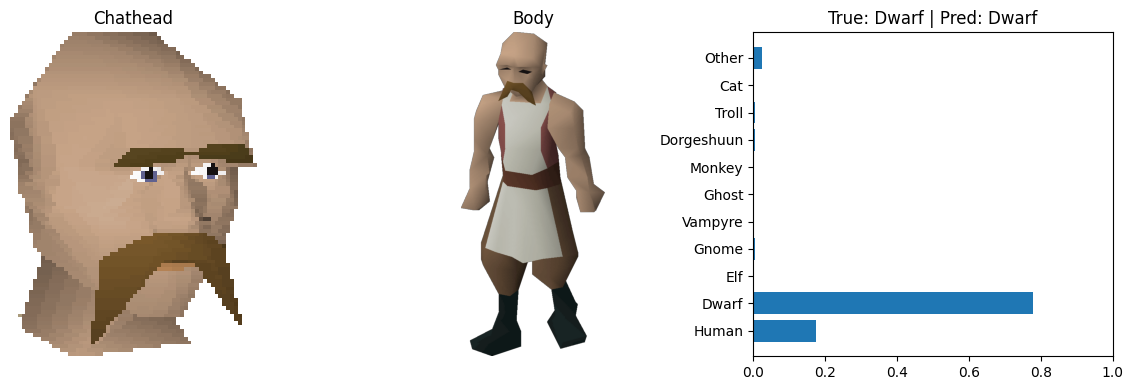

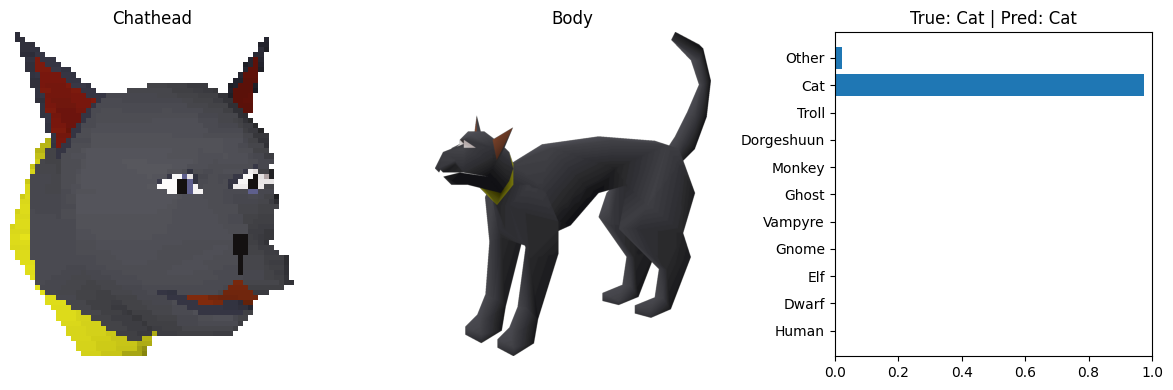

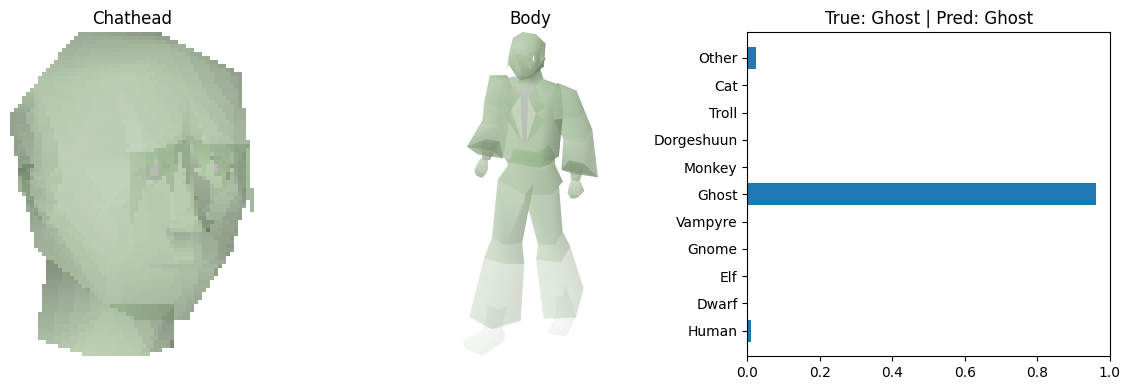

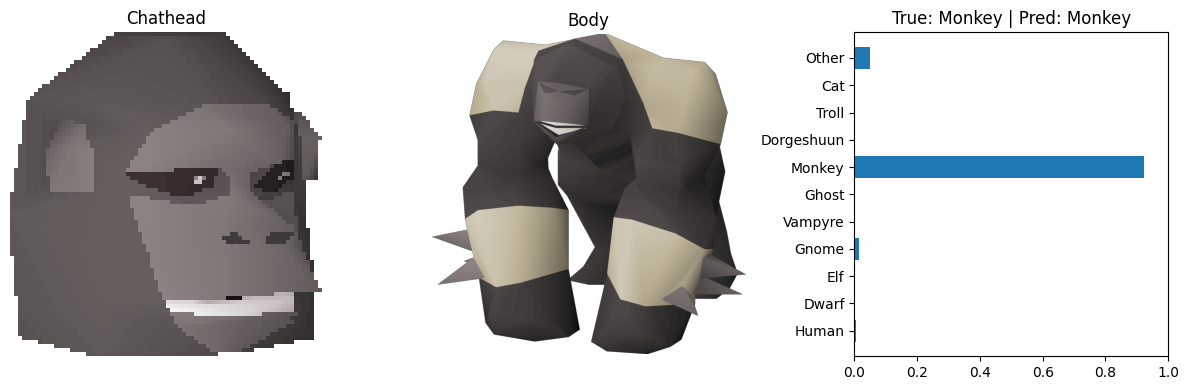

In [18]:
show_prediction("Dwarf")
show_prediction("Cat")
show_prediction("Ghost")
show_prediction("Monkey")

# Trying to investigate the model, see what's within the black box

# Grad-CAM
Shows pixels in the input image at each layer that the model is paying the most attention to. It's a heatmap. "The model looked here to make its prediction."

The heatmap goes blue (low attention) → green → yellow → red (high attention).

In [19]:
def grad_cam(model, chathead_tensor, body_tensor, class_idx, target_layer):
    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_backward_hook(backward_hook)

    model.zero_grad()
    output = model(chathead_tensor, body_tensor)
    output[0, class_idx].backward()

    fh.remove()
    bh.remove()

    grad = gradients[0].squeeze()
    act = activations[0].squeeze()
    weights = grad.mean(dim=(1, 2))
    cam = (weights[:, None, None] * act).sum(0)
    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam.detach().cpu().numpy()

def show_grad_cam(class_name):
    row = test_df[test_df["label"] == class_name].sample(1).iloc[0]

    chathead_img = Image.open(f"/content/cv-final/data/chatheads/{row['id']}.png").convert("RGB")
    body_img = Image.open(f"/content/cv-final/data/bodies/{row['id']}.png").convert("RGB")

    chathead_t = eval_transform(chathead_img).unsqueeze(0).to(device).requires_grad_(True)
    body_t = eval_transform(body_img).unsqueeze(0).to(device).requires_grad_(True)

    with torch.no_grad():
        pred_idx = model(chathead_t, body_t).argmax(1).item()

    layer_names = ["layer1\n(edges)", "layer2\n(textures)", "layer3\n(parts)", "layer4\n(concepts)"]

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))

    for row_idx, (backbone, img, label) in enumerate([
        (model.chathead_cnn, chathead_img, "Chathead"),
        (model.body_cnn, body_img, "Body")
    ]):
        layers = [backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4]

        axes[row_idx, 0].imshow(img)
        axes[row_idx, 0].set_title(f"Original\n({label})")
        axes[row_idx, 0].axis("off")

        for col, (layer, name) in enumerate(zip(layers, layer_names)):
            cam = grad_cam(model, chathead_t, body_t, pred_idx, layer)
            scale = img.width // cam.shape[1]
            axes[row_idx, col+1].imshow(img)
            axes[row_idx, col+1].imshow(
                plt.cm.jet(cam.repeat(scale, axis=0).repeat(scale, axis=1))[:,:,:3],
                alpha=0.5, extent=[0, img.width, img.height, 0]
            )
            axes[row_idx, col+1].set_title(name, fontsize=8)
            axes[row_idx, col+1].axis("off")

    plt.suptitle(f"True: {class_name} | Pred: {CLASS_NAMES[pred_idx]}", fontsize=12)
    plt.tight_layout()
    plt.show()

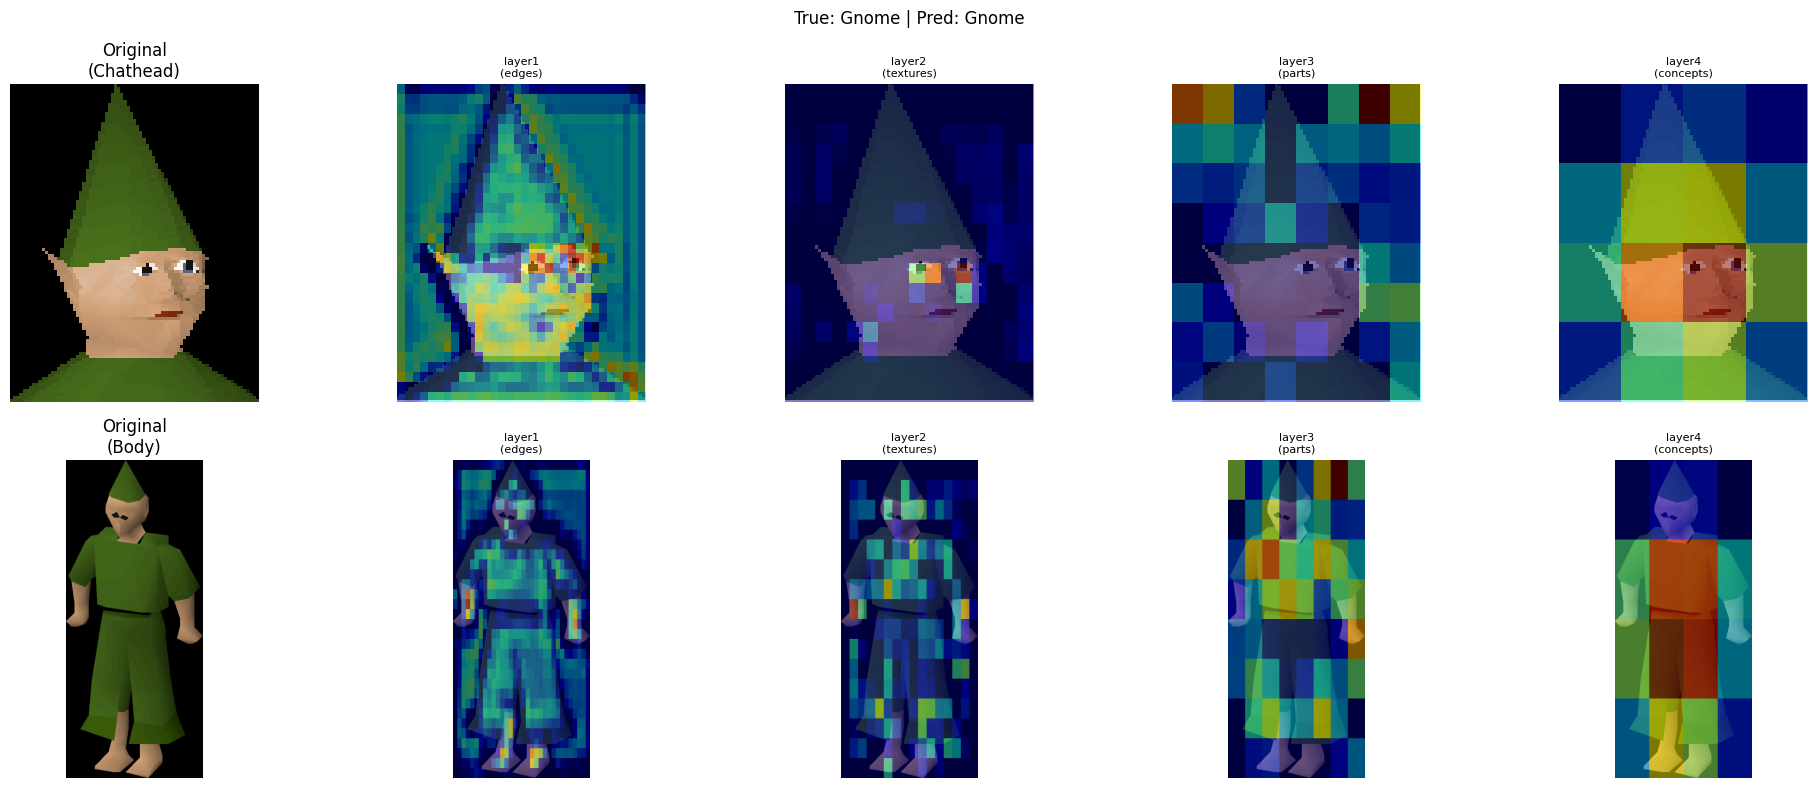

In [23]:
show_grad_cam("Gnome")

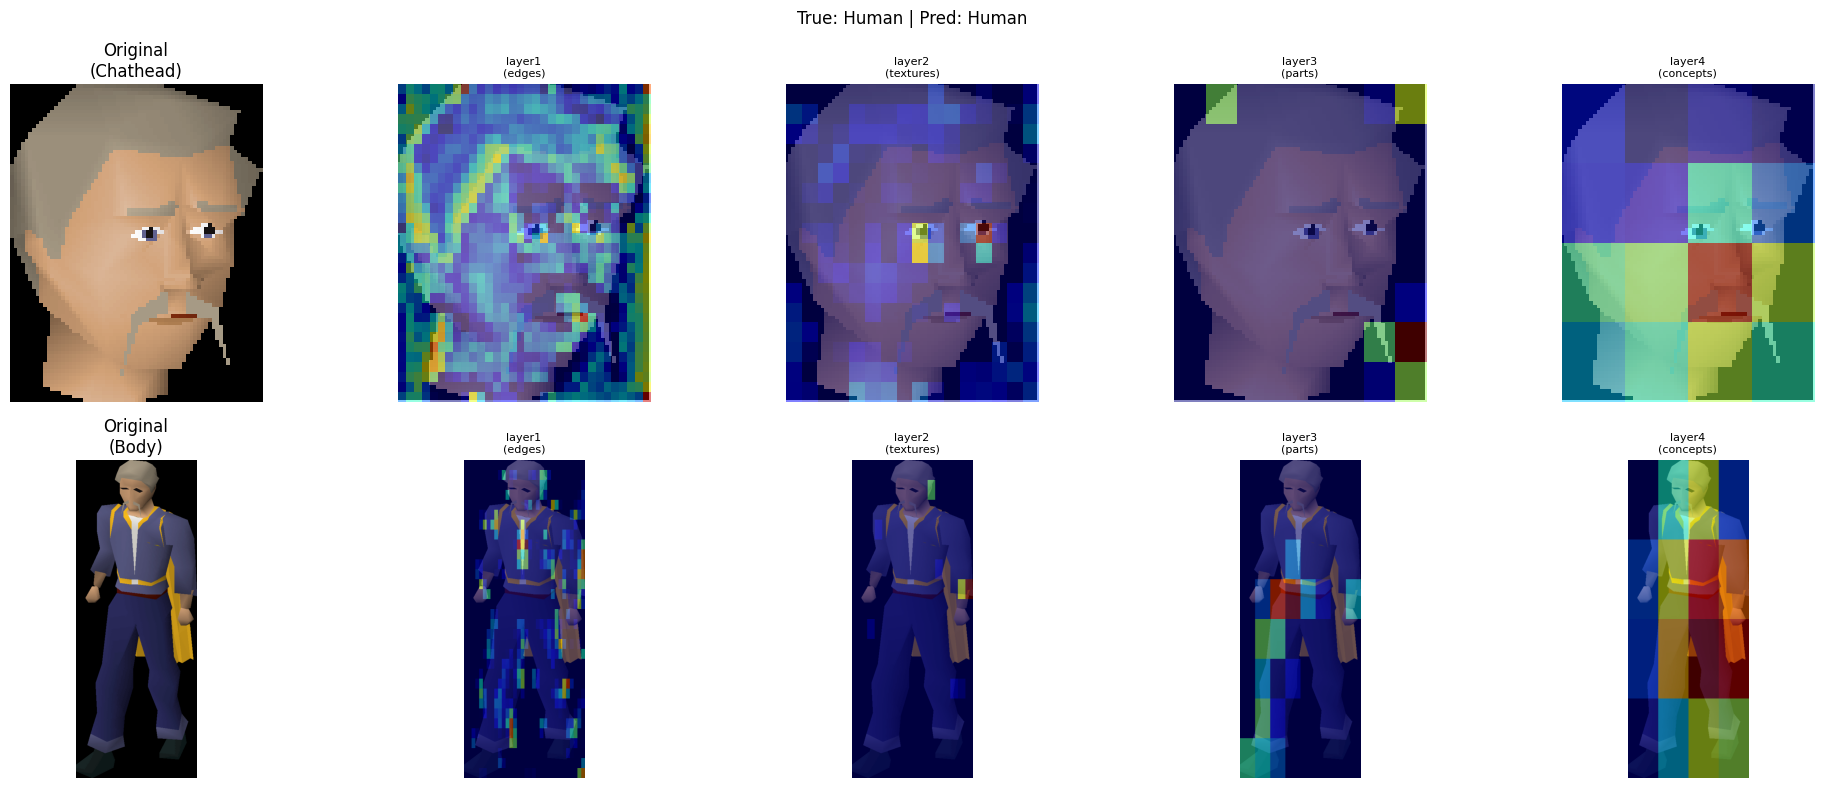

In [24]:
show_grad_cam("Human")

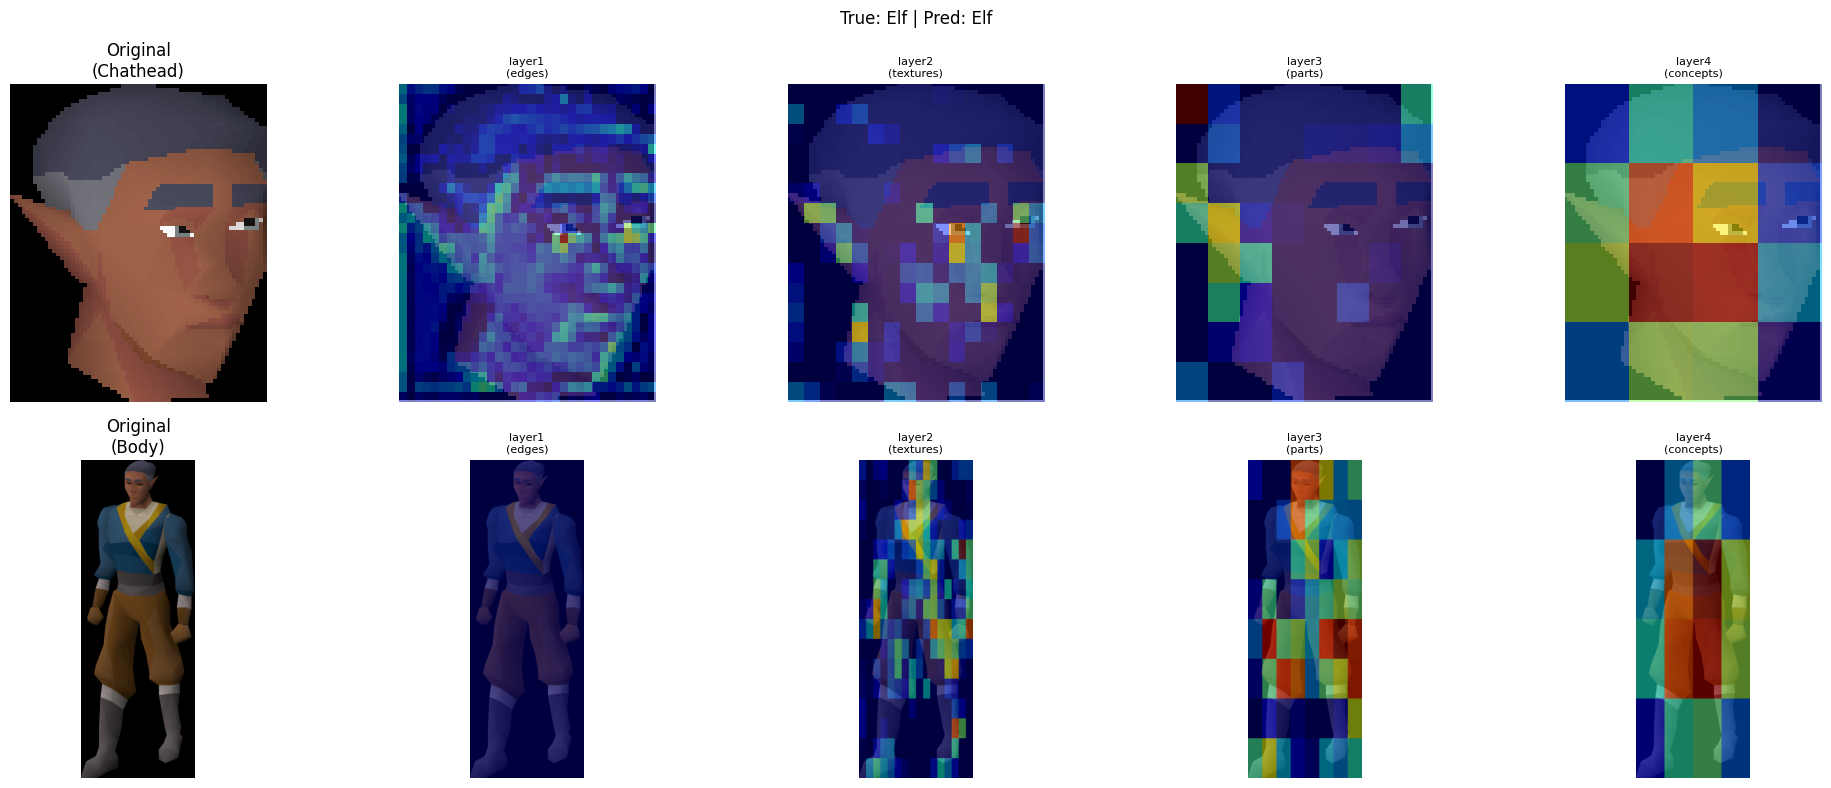

In [25]:
show_grad_cam("Elf")

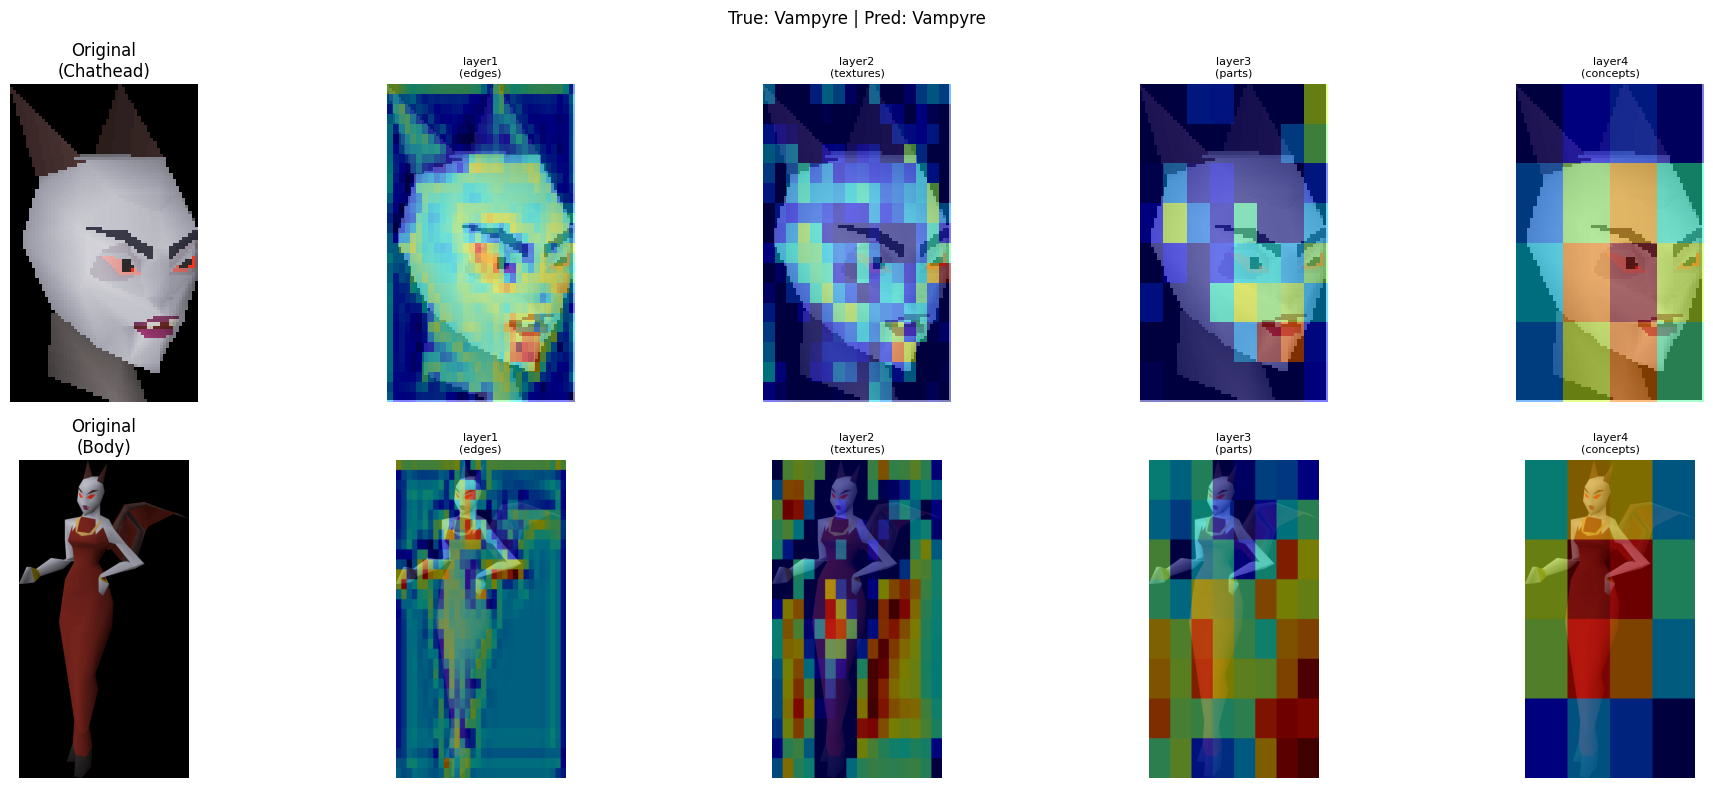

In [26]:
show_grad_cam("Vampyre")

# Filter visualization

Directly visualize what each filter in a layer is looking for by finding the input that maximizes its activation. Early filters look like Gabor filters (oriented edges, color blobs), later ones look like textures and parts. More interpretable than Grad-CAM for understanding what each layer learned in general.

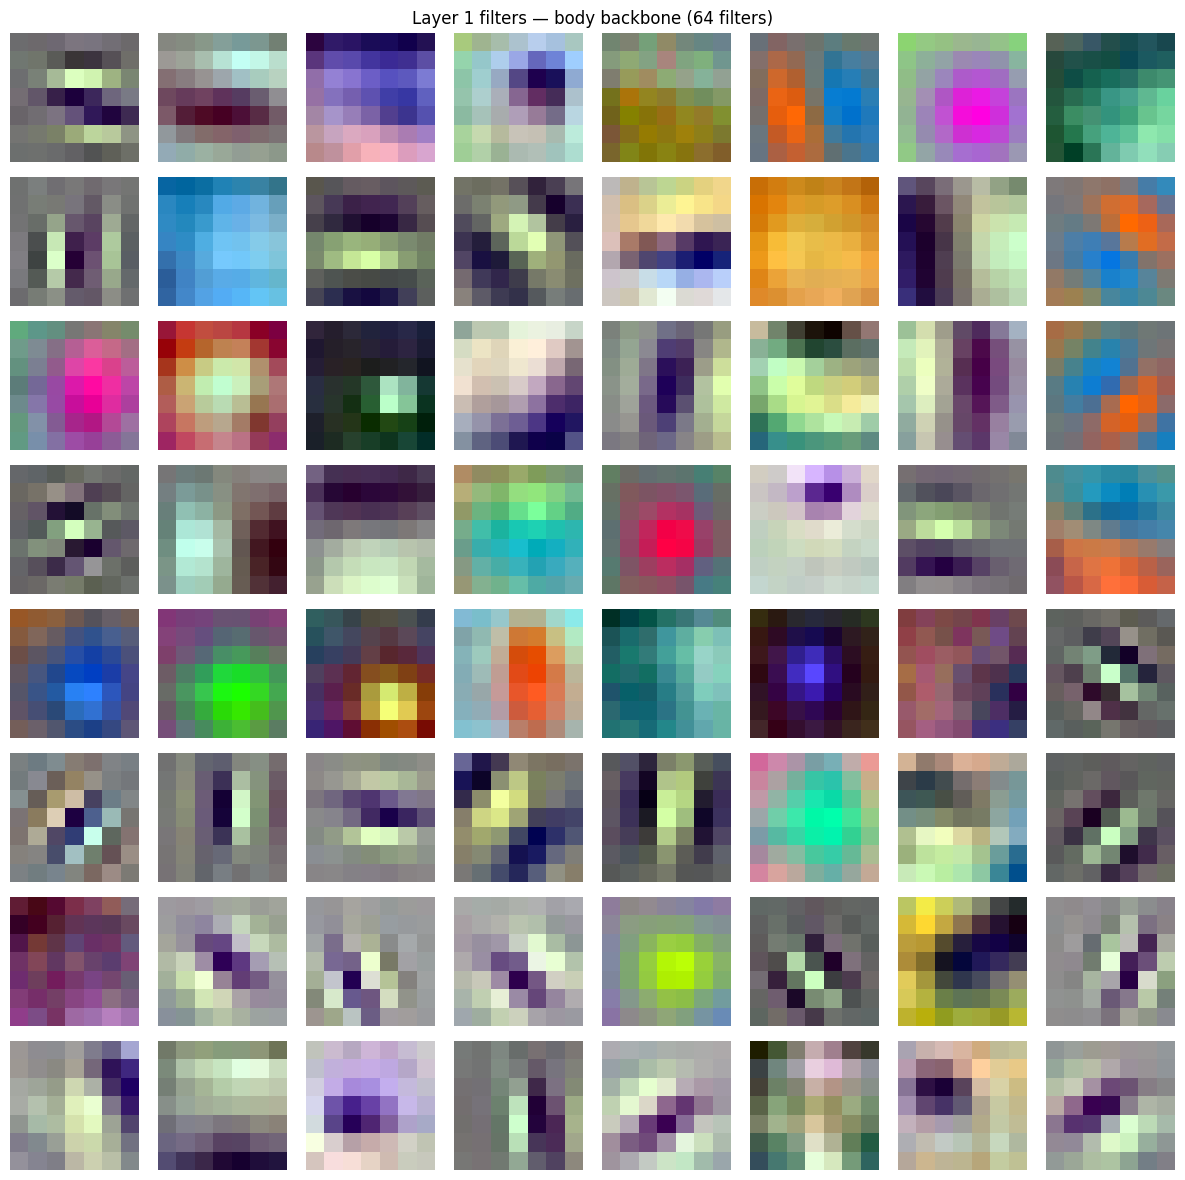

In [27]:
# visualize filters in layer1 of body backbone
filters = model.body_cnn.conv1.weight.detach().cpu()

# normalize each filter to [0,1] for display
def normalize_filter(f):
    f = f - f.min()
    f = f / (f.max() + 1e-8)
    return f

n = 64  # conv1 has 64 filters
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    f = normalize_filter(filters[i])
    # filters are 3-channel (RGB) so we can display as color image
    ax.imshow(f.permute(1, 2, 0))
    ax.axis("off")

plt.suptitle("Layer 1 filters — body backbone (64 filters)", fontsize=12)
plt.tight_layout()
plt.show()

# Activation map

instead of Grad-CAM (which is gradient-weighted), just look at the raw feature map outputs at each layer for a given input. You'd see which of the 64/128/256/512 channels fired and where.

In [28]:
def show_activations(class_name, layer, layer_name, n_filters=16):
    row = test_df[test_df["label"] == class_name].sample(1).iloc[0]

    body_img = Image.open(f"/content/cv-final/data/bodies/{row['id']}.png").convert("RGB")
    body_t = eval_transform(body_img).unsqueeze(0).to(device)

    activations = []
    def hook(module, input, output):
        activations.append(output)
    h = layer.register_forward_hook(hook)
    with torch.no_grad():
        model(eval_transform(Image.open(f"/content/cv-final/data/chatheads/{row['id']}.png").convert("RGB")).unsqueeze(0).to(device), body_t)
    h.remove()

    acts = activations[0].squeeze().cpu()  # shape: (n_channels, h, w)

    # pick the n_filters most activated channels
    mean_acts = acts.mean(dim=(1, 2))
    top_idx = mean_acts.argsort(descending=True)[:n_filters]

    fig, axes = plt.subplots(2, n_filters // 2, figsize=(20, 5))
    for ax, idx in zip(axes.flat, top_idx):
        act = acts[idx]
        ax.imshow(act, cmap='viridis')
        ax.set_title(f"filter {idx.item()}", fontsize=7)
        ax.axis("off")

    plt.suptitle(f"{class_name} (id={row['id']}) — top {n_filters} activated filters at {layer_name}")
    plt.tight_layout()
    plt.show()

Shows the 16 most activated filters at layer1 vs layer4 for the same NPC — you'll see layer1 is edges/blobs, layer4 is more abstract/sparse.

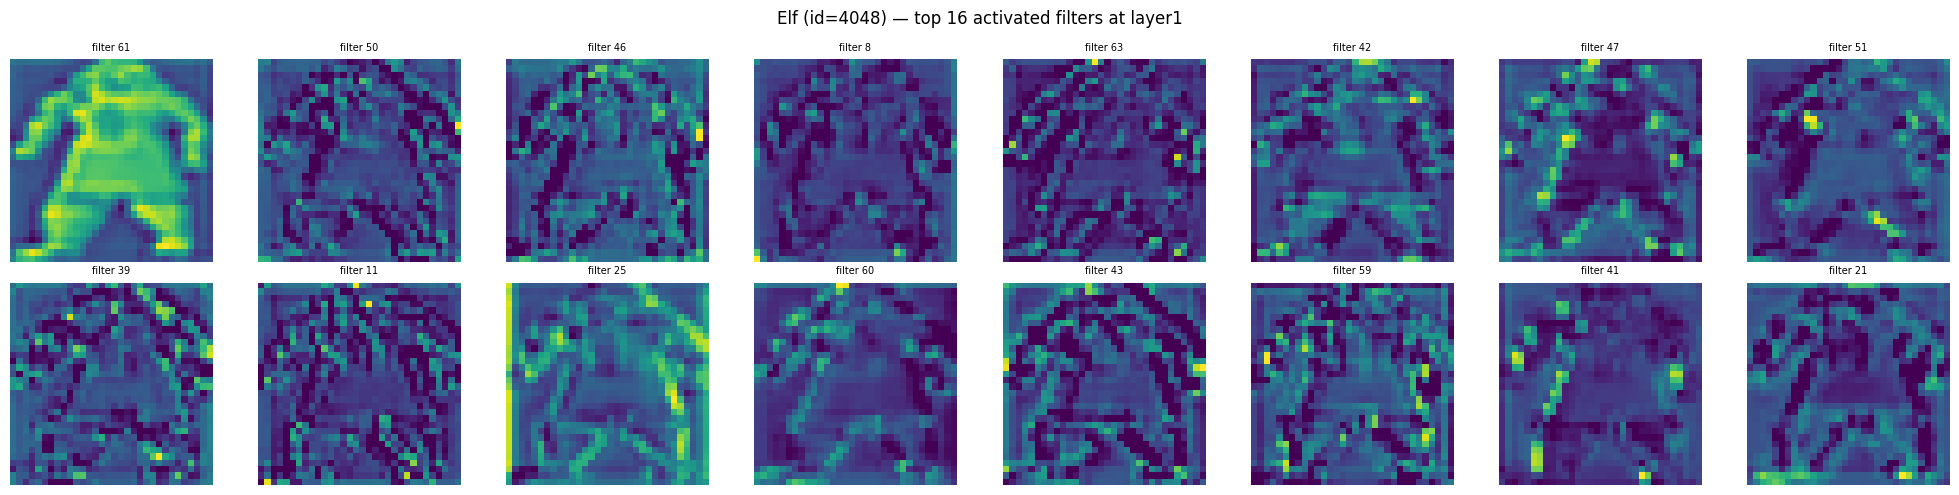

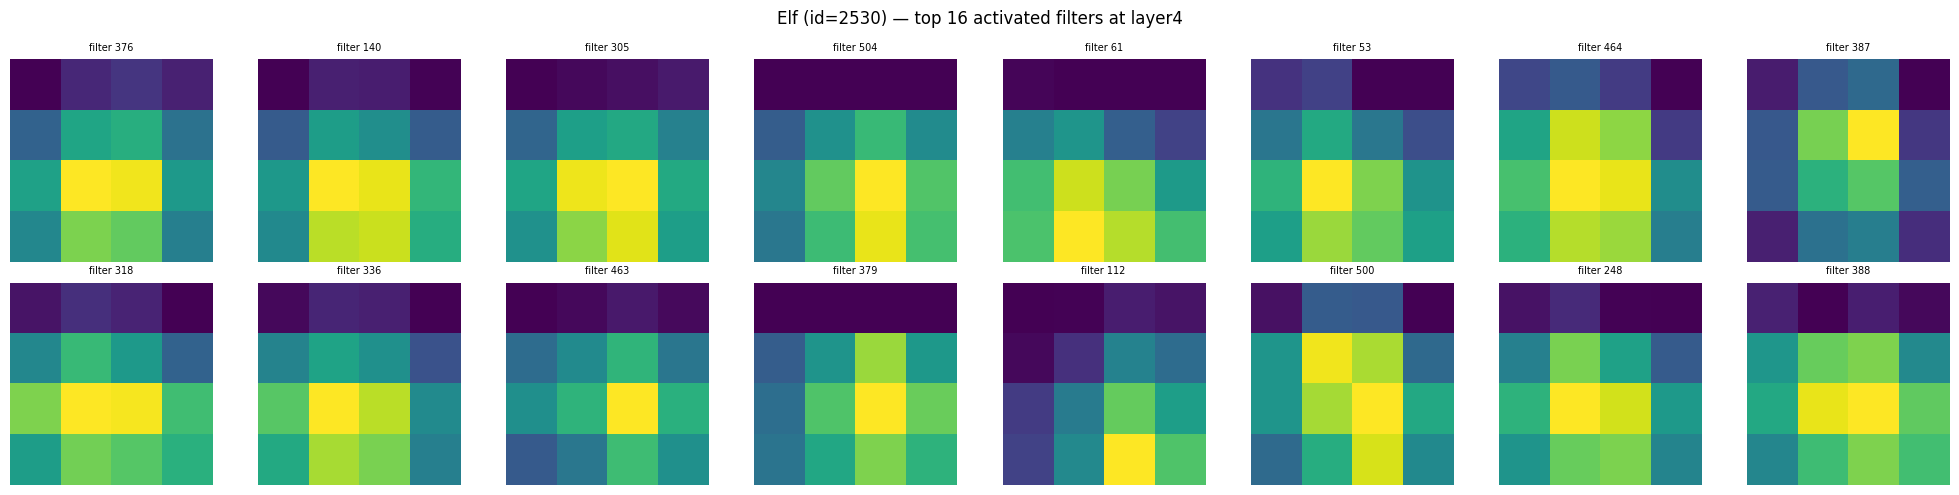

In [29]:
show_activations("Elf", model.body_cnn.layer1, "layer1")
show_activations("Elf", model.body_cnn.layer4, "layer4")

# t-SNE on layer features

xtract the feature vector at a given layer for all 521 test images, run t-SNE, color by class. Do this at layer1, layer2, layer3, layer4 and watch the classes go from overlapping blobs to clean clusters as you go deeper. Very compelling visualization for showing the network is actually learning.

See clusters form by class

### Proves model learned separations (each class gets its own cluster, ech cluster is separated), but doesn't tell us why

Grad-CAM actually probably best for that. Grad-CAM can show model focusing on eyes for Vampyre, pointy ears for Elf, etc

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


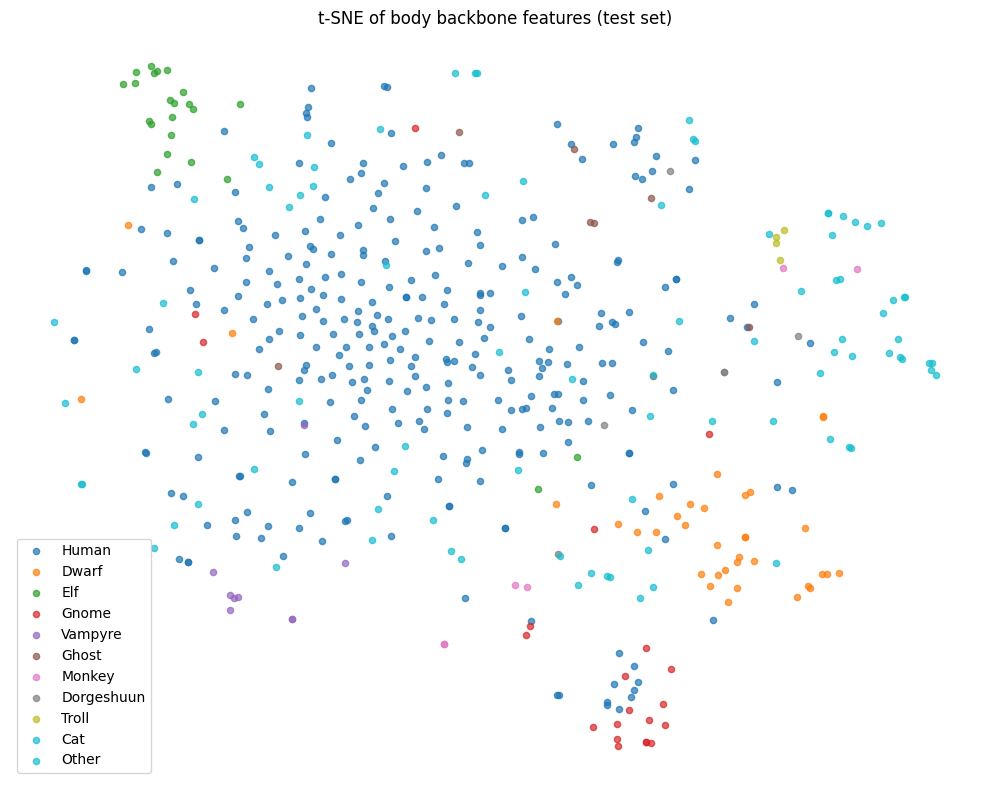

In [30]:
from sklearn.manifold import TSNE

# extract 512-dim feature vectors from body backbone (before classifier)
model.eval()
features, labels_list = [], []

with torch.no_grad():
    for chathead, body, labels in test_loader:
        body_feats = model.body_cnn(body.to(device)).cpu().numpy()
        features.append(body_feats)
        labels_list.extend(labels.tolist())

features = np.vstack(features)
labels_arr = np.array(labels_list)

# run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedded = tsne.fit_transform(features)

# plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))
for i, cls in enumerate(CLASS_NAMES):
    mask = labels_arr == i
    ax.scatter(embedded[mask, 0], embedded[mask, 1], label=cls, alpha=0.7, s=20, color=colors[i])

ax.legend()
ax.set_title("t-SNE of body backbone features (test set)")
ax.axis("off")
plt.tight_layout()
plt.show()